# 08 – Performance in kWh/m³ vor und nach der Begehung

Nachrechnung der ÜZ-Folie „Vergleich Gesamteffizienz vor und nach der Optimierung von HAST" mit unseren Zählerdaten.

- **Kennzahl:** entnommene Energie je m³ Heizwasser, aufgetragen gegen die Außentemperatur
- **Aussage der Folie:** optimierte Stationen liegen rund 2,12 kWh/m³ bzw. 13,4 % höher (bei ca. 8,8 °C)
- **Einordnung:** 1 kWh/m³ ≈ 0,86 K Spreizung. Hoch ist gut, der Rücklauf bleibt kühl.

Was wir zusätzlich zur Folie machen:

- Signifikanztest auf den Steigungsunterschied
- Check, ob beide Gruppen denselben Temperaturbereich abdecken
- zweite Variante mit dem eigenen Begehungsdatum je Station statt einem gemeinsamen Stichtag

Code: `src/performance.py`, Tests: `tests/test_performance.py`

## 1 – Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

from src import performance as perf
from src import load_begehungen as lb
from src import load_timeseries as lts
from src import weather

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (10, 6)

OUTPUTS = Path.cwd().parent / "outputs"
OUTPUTS.mkdir(exist_ok=True)

### Parameter

- `MIN_VOLUME_M3`: Mindest-Tagesvolumen, darunter ist Energie/Volumen nur Rauschen
- `BAND`: Plausibilitätsband der Kennzahl
- `PUFFER_TAGE`: blendet in Variante B die Einregelphase um die Begehung aus

Wie viel an welchem Filter hängen bleibt, zeigt die Filterbilanz weiter unten.

In [2]:
MIN_VOLUME_M3 = perf.MIN_VOLUME_M3   #0,5 m3 je Tag
BAND = perf.BAND_KWH_M3              #(-2, 70) kWh/m3
MIN_STUNDEN = perf.MIN_STUNDEN       #20 von 24 gueltigen Stundenintervallen
PUFFER_TAGE = 7                      #Einregelphase um die Begehung, Variante B
STICHTAG_UZ = "2024-09-30"           #Stichtag der UEZ-Folie

#Spaltennamen der Rohexporte auf das Schema von features.features_for_meter
SPALTEN = {
    "Energy (kWh)": "energy",
    "Volume flow (l/h)": "flow",
    "Power (kW)": "power",
    "Temperature difference (°C)": "dt",
    "Flow temperature (°C)": "vl",
    "Return temperature (°C)": "rt",
    "Volume (m³)": "volume",
}

## 2 – Daten laden

In [3]:
def lade_serien():
    """Alle Zaehlerreihen auf dem Stundenraster, Ladefehler werden benannt."""
    serien, fehler = {}, []
    for zid in sorted(lts.discover_meter_files()):
        try:
            df = lts.load_meter_timeseries(zid)
        except Exception as exc:
            fehler.append({"meter": zid, "grund": str(exc).split(" - ")[0]})
            continue
        df = df.rename(columns=SPALTEN).set_index("Timestamp").sort_index()
        #Rohexporte stehen minutenversetzt (13:01); auf die volle Stunde legen
        df.index = df.index.floor("h")
        serien[zid] = df[~df.index.duplicated(keep="last")]
    return serien, pd.DataFrame(fehler)


serien, ladefehler = lade_serien()
hist_von = min(d.index[0].normalize() for d in serien.values() if len(d))
hist_bis = max(d.index[-1].normalize() for d in serien.values() if len(d))

print(f"{len(serien)} Zaehlerreihen geladen, {len(ladefehler)} nicht ladbar")
print(f"Historie insgesamt: {hist_von.date()} .. {hist_bis.date()}")

100 Zaehlerreihen geladen, 1 nicht ladbar
Historie insgesamt: 2021-05-31 .. 2025-07-11


In [4]:
t_out = weather.load_outdoor_temperature(hist_von,
                                         hist_bis + pd.Timedelta(hours=23),
                                         allow_download=False)
print(f"Aussentemperatur: {len(t_out)} Stunden, "
      f"{int(t_out['interpolated'].sum())} davon interpoliert")

begehungen = (lb.begehungen_mit_zaehler(available=set(serien))
                .dropna(subset=["meter", "datum"]))
begehungen["meter"] = begehungen["meter"].astype(int)
#bei mehreren Begehungen je Station trennt die erste
erste_begehung = begehungen.sort_values("datum").groupby("meter")["datum"].first()

print(f"{len(begehungen)} Begehungen mit Zaehlernummer, "
      f"{begehungen['meter'].nunique()} Zaehler")
display(begehungen["datum"].dt.to_period("M").value_counts().sort_index()
        .rename("Begehungen").to_frame())

Aussentemperatur: 36068 Stunden, 7 davon interpoliert


C:\pv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


58 Begehungen mit Zaehlernummer, 56 Zaehler


,Begehungen
datum,
2024-08,2
2024-09,34
2024-10,3
2024-11,13
2024-12,1
2025-03,1
2025-09,4


**Stichtag:** Der Stichtag der Folie (2024-09-30) passt auch bei uns.

- 36 von 58 Begehungen liegen davor, Median ist der 2024-09-20
- Problem: vier Begehungen vom September 2025 liegen hinter dem Ende der Zählerhistorie (2025-07-11). Diese Stationen haben keine Nachher-Phase, landen beim festen Stichtag aber trotzdem in „optimiert".
- Deshalb gibt es Variante B.

## 3 – Kennzahl aus den kumulativen Kanälen

Energie und Volumen sind Zählerstände, die Tageswerte entstehen aus Stundendifferenzen. Einzelne Stundenintervalle fliegen raus bei:

- Rücksprung des Zählerstands (Überlauf, Gerätetausch)
- Intervall über eine Messlücke
- physikalisch unmöglichem Sprung nach vorn

Der restliche Tag bleibt drin.

In [5]:
tab = perf.performance_tabelle(serien, min_volume_m3=MIN_VOLUME_M3,
                               band=BAND, min_stunden=MIN_STUNDEN)
tab = perf.mit_aussentemperatur(tab, t_out)
print(f"{len(tab):,} Stationstage aus {tab['meter'].nunique()} Zaehlern")
display(perf.filterbilanz(tab))

92,876 Stationstage aus 100 Zaehlern


,bedingung,tage,anteil
0,Tagesreihen gesamt,92876,1.000000
1,Volumen unter Schwelle,35679,0.384157
2,ausserhalb Plausibilitaetsband,0,0.000000
3,Abdeckung unter Mindeststunden,22403,0.241214
4,gueltig,57121,0.615024


- Knapp 62 % der Stationstage bleiben übrig.
- Größter Posten: Tage unter der Volumenschwelle (Sommer, Stillstand).
- Das Plausibilitätsband greift bei keinem einzigen Tag.

### Gegenprobe gegen die gemessene Spreizung

Die Kennzahl in Kelvin umgerechnet muss ungefähr zur gemessenen, durchflussgewichteten Spreizung passen. Wenn nicht, stimmen Energie-, Volumen- und Temperaturkanal des Zählers nicht zusammen.

In [6]:
gegen = tab[tab["gueltig"]].dropna(subset=["dt_abweichung_k"])
print(gegen["dt_abweichung_k"].describe()[["count", "mean", "50%", "std"]])

je_meter = (gegen.groupby("meter")["dt_abweichung_k"]
            .agg(["median", "count"])
            .sort_values("median"))
auffaellig = je_meter[je_meter["median"].abs() > 3.0]
print(f"\nZaehler mit Medianabweichung ueber 3 K: {len(auffaellig)} "
      f"von {len(je_meter)}")
display(auffaellig)

count    55122.000000
mean        -0.737237
50%         -0.462347
std          5.599986
Name: dt_abweichung_k, dtype: float64

Zaehler mit Medianabweichung ueber 3 K: 13 von 98


,median,count
meter,,
53198226,-7.083191,884
68956355,-6.201846,934
68956360,-5.608822,948
68956372,-4.274222,870
72167782,-3.852563,945
72135442,-3.670143,970
72167793,-3.490114,543
72135490,-3.168759,852
80912188,3.374588,442


- Abweichung im Median rund 0,5 K, das passt zur stündlichen Abtastung.
- Die auffälligen Zähler bleiben hier erstmal drin. Die Ursache ist nicht geklärt, ein Ausschluss würde nur die Fallzahl senken.

## 4 – Zwei Auswertungsvarianten

- **Variante A:** ein gemeinsamer Stichtag für alle Stationen (wie auf der Folie)
- **Variante B:** jede Station bekommt ihr eigenes Begehungsdatum als Trennpunkt

Warum B: Unsere Begehungen verteilen sich über 13 Monate. Mit einem gemeinsamen Stichtag landen Tage in der falschen Gruppe.

Grundmenge für beide: gültige Stationstage von Stationen mit dokumentierter Begehung.

In [7]:
basis = tab[tab["gueltig"] & tab["meter"].isin(erste_begehung.index)].copy()
basis = basis.dropna(subset=["t_out_tag"])
print(f"Grundmenge: {len(basis):,} Stationstage, "
      f"{basis['meter'].nunique()} Zaehler")

var_a = perf.gruppe_fester_stichtag(basis, STICHTAG_UZ)
var_b = perf.gruppe_je_station(basis, erste_begehung.to_dict(),
                               puffer_tage=PUFFER_TAGE)
ohne_gruppe = int(var_b["gruppe"].isna().sum())
var_b = var_b.dropna(subset=["gruppe"])

print(f"Variante A: {len(var_a):,} Tage")
print(f"Variante B: {len(var_b):,} Tage, {ohne_gruppe} Tage im Puffer "
      f"von +/- {PUFFER_TAGE} Tagen um die Begehung ausgeblendet")

Grundmenge: 28,796 Stationstage, 51 Zaehler


Variante A: 28,796 Tage
Variante B: 28,319 Tage, 477 Tage im Puffer von +/- 7 Tagen um die Begehung ausgeblendet


## 5 – Regression je Gruppe

In [8]:
def auswerten(daten, name):
    """Beide Geraden, Bezugspunkt, Delta und Interaktionstest in einem Schritt."""
    fits = perf.regression_je_gruppe(daten, cluster="meter")
    t_ref = float(pd.to_numeric(daten["t_out_tag"], errors="coerce").mean())
    zeile = fits.set_index("gruppe")
    delta = perf.delta_am_bezugspunkt(
        zeile.loc[perf.GRUPPE_VOR, "steigung"],
        zeile.loc[perf.GRUPPE_VOR, "achsenabschnitt"],
        zeile.loc[perf.GRUPPE_NACH, "steigung"],
        zeile.loc[perf.GRUPPE_NACH, "achsenabschnitt"],
        t_ref)
    modell = perf.interaktionsmodell(daten, cluster="meter")
    delta_ci = perf.delta_aus_interaktion(modell, t_ref)
    print(f"--- {name} --- Bezugspunkt {t_ref:.2f} °C")
    return {"name": name, "daten": daten, "fits": fits, "t_ref": t_ref,
            "delta": delta, "modell": modell, "delta_ci": delta_ci}


erg_a = auswerten(var_a, "Variante A (fester Stichtag)")
erg_b = auswerten(var_b, "Variante B (stationseigenes Begehungsdatum)")

spalten = ["gruppe", "n", "meter", "steigung", "steigung_ci_low",
           "steigung_ci_high", "achsenabschnitt", "r2", "t_out_mittel"]
for erg in (erg_a, erg_b):
    print(f"\n{erg['name']}")
    display(erg["fits"][spalten].round(3))

--- Variante A (fester Stichtag) --- Bezugspunkt 9.85 °C
--- Variante B (stationseigenes Begehungsdatum) --- Bezugspunkt 9.81 °C

Variante A (fester Stichtag)


,gruppe,n,meter,steigung,steigung_ci_low,steigung_ci_high,achsenabschnitt,r2,t_out_mittel
0,unoptimiert,17233,48,-0.674,-0.862,-0.486,27.737,0.188,11.094
1,optimiert,11563,48,-0.652,-0.800,-0.504,30.380,0.167,7.995



Variante B (stationseigenes Begehungsdatum)


,gruppe,n,meter,steigung,steigung_ci_low,steigung_ci_high,achsenabschnitt,r2,t_out_mittel
0,unoptimiert,17834,48,-0.702,-0.911,-0.493,28.194,0.195,10.818
1,optimiert,10485,45,-0.615,-0.714,-0.516,30.059,0.165,8.093


**Konfidenzintervalle:** clusterrobust mit der Zählernummer als Cluster. Tage derselben Station sind nicht unabhängig, die Standardformel liefert hier Standardfehler, die etwa um Faktor fünf zu eng sind.

In [9]:
zeilen = []
for erg in (erg_a, erg_b):
    d, m, ci = erg["delta"], erg["modell"], erg["delta_ci"]
    zeilen.append({
        "Variante": erg["name"],
        "t_ref (°C)": erg["t_ref"],
        "y unoptimiert": d["y_vor"],
        "y optimiert": d["y_nach"],
        "Delta (kWh/m³)": d["delta_kwh_m3"],
        "Delta (K)": d["delta_k"],
        "Delta (%)": d["delta_prozent"],
        "Delta KI unten": ci["delta_ci"][0],
        "Delta KI oben": ci["delta_ci"][1],
        "Delta p": ci["delta_p"],
        "Steigungsdiff.": m["steigungsdifferenz"],
        "Steigungsdiff. p": m["steigungsdifferenz_p"],
        "n": m["n"],
        "Stationen": m["n_cluster"],
    })
ergebnis = pd.DataFrame(zeilen)
display(ergebnis.round(4).set_index("Variante").T)

Variante,Variante A (fester Stichtag),Variante B (stationseigenes Begehungsdatum)
t_ref (°C),9.8497,9.8093
y unoptimiert,21.0978,21.3090
y optimiert,23.9609,24.0265
Delta (kWh/m³),2.8631,2.7175
Delta (K),2.4618,2.3366
Delta (%),13.5706,12.7527
Delta KI unten,0.7813,0.4892
Delta KI oben,4.9449,4.9458
Delta p,0.0080,0.0179
Steigungsdiff.,0.0224,0.0869


**Ergebnis:**

- Der **Höhenabstand** der Geraden am Bezugspunkt ist in beiden Varianten klar von null verschieden.
- Der Unterschied der **Steigungen** ist es nicht: Variante A 0,02 (p ≈ 0,79), Variante B 0,09 (p ≈ 0,35).
- „Optimierte Anlagen fallen im Milden flacher ab" lässt sich mit unseren Daten also nicht belegen, der Niveauunterschied schon.

### Gegenprobe mit Volumengewichtung

Die Folie zeichnet die Blasen nach Volumen, fittet aber offenbar ungewichtet. Hier derselbe Fit gewichtet mit dem Tagesvolumen.

In [10]:
for erg in (erg_a, erg_b):
    gew = perf.regression_je_gruppe(erg["daten"], gewicht="volumen_m3",
                                    cluster="meter")
    print(f"\n{erg['name']} – mit Tagesvolumen gewichtet")
    display(gew[["gruppe", "n", "steigung", "achsenabschnitt", "r2"]].round(3))


Variante A (fester Stichtag) – mit Tagesvolumen gewichtet


,gruppe,n,steigung,achsenabschnitt,r2
0,unoptimiert,17233,-0.774,21.977,0.227
1,optimiert,11563,-0.802,27.289,0.161



Variante B (stationseigenes Begehungsdatum) – mit Tagesvolumen gewichtet


,gruppe,n,steigung,achsenabschnitt,r2
0,unoptimiert,17834,-0.784,22.355,0.223
1,optimiert,10485,-0.804,27.230,0.170


- Volumengewichtet fällt die optimierte Gerade sogar etwas steiler ab als die unoptimierte.
- Der Höhenabstand bleibt.
- Die Steigungsaussage hängt also an der Gewichtung, nicht an den Anlagen.

## 6 – Decken beide Gruppen denselben Temperaturbereich ab?

Fehlt auf der Folie. Liegen die beiden Punktwolken auf unterschiedlichen Temperaturbereichen, vergleicht man verschiedene Betriebsbereiche und der Wert am Bezugspunkt wäre extrapoliert.

In [11]:
for erg in (erg_a, erg_b):
    print(f"\n{erg['name']}")
    display(perf.temperaturueberdeckung(erg["daten"],
                                        t_ref=erg["t_ref"]).round(2))


Variante A (fester Stichtag)


,gruppe,n,mittel,q05,q25,q50,q75,q95,n_nahe_t_ref,anteil_nahe_t_ref,t_ref_im_bereich
0,unoptimiert,17233,11.09,-1.27,6.44,10.43,16.88,22.32,3645,0.21,True
1,optimiert,11563,8.00,-1.60,2.84,6.99,12.40,21.20,2327,0.20,True



Variante B (stationseigenes Begehungsdatum)


,gruppe,n,mittel,q05,q25,q50,q75,q95,n_nahe_t_ref,anteil_nahe_t_ref,t_ref_im_bereich
0,unoptimiert,17834,10.82,-1.27,5.91,10.09,16.72,22.32,3748,0.21,True
1,optimiert,10485,8.09,-1.60,2.84,7.12,12.51,21.20,2046,0.20,True


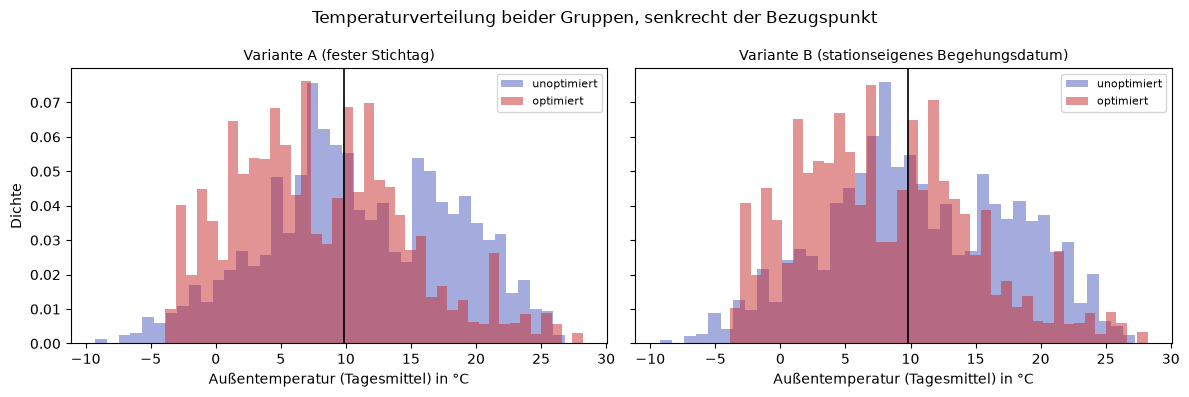

In [12]:
fig, achsen = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, erg in zip(achsen, (erg_a, erg_b)):
    for name, farbe in ((perf.GRUPPE_VOR, "#4b5bbf"),
                        (perf.GRUPPE_NACH, "#c62828")):
        werte = erg["daten"].loc[erg["daten"]["gruppe"] == name, "t_out_tag"]
        ax.hist(werte, bins=40, alpha=0.5, color=farbe, label=name,
                density=True)
    ax.axvline(erg["t_ref"], color="black", linewidth=1.2)
    ax.set_title(erg["name"], fontsize=10)
    ax.set_xlabel("Außentemperatur (Tagesmittel) in °C")
    ax.legend(fontsize=8)
achsen[0].set_ylabel("Dichte")
fig.suptitle("Temperaturverteilung beider Gruppen, senkrecht der Bezugspunkt")
fig.tight_layout()
plt.show()

- Der Bezugspunkt liegt in beiden Gruppen und Varianten im belegten Bereich, rund ein Fünftel der Tage liegt im Band ±2 K. Es wird nichts extrapoliert.
- Die Gruppe „optimiert" ist aber im Mittel 2,7 bis 3,1 K kälter, ihr unteres Quartil beginnt bei knapp 3 °C statt 6 °C.
- Für den Höhenabstand am Bezugspunkt ist das unkritisch.
- Für die Steigungen nicht: die unoptimierte Gerade hängt stärker am warmen Ende, die optimierte am kalten. Ein Teil des Steigungsunterschieds der Folie kann allein daher kommen.

## 7 – Die Grafik

Knapp 29 000 Tagespunkte ergeben als Streudiagramm nur eine Farbfläche. Deshalb:

- **Hauptgrafik:** ein Punkt je Station, Gruppe und 2-K-Temperaturklasse. Höhe = volumengewichtetes Mittel der Kennzahl, Fläche = Volumen.
- Die Regressionsgeraden kommen weiterhin aus dem Fit über die Tageswerte.
- **Darunter:** dieselbe Auswertung unverdichtet auf Tagesebene.

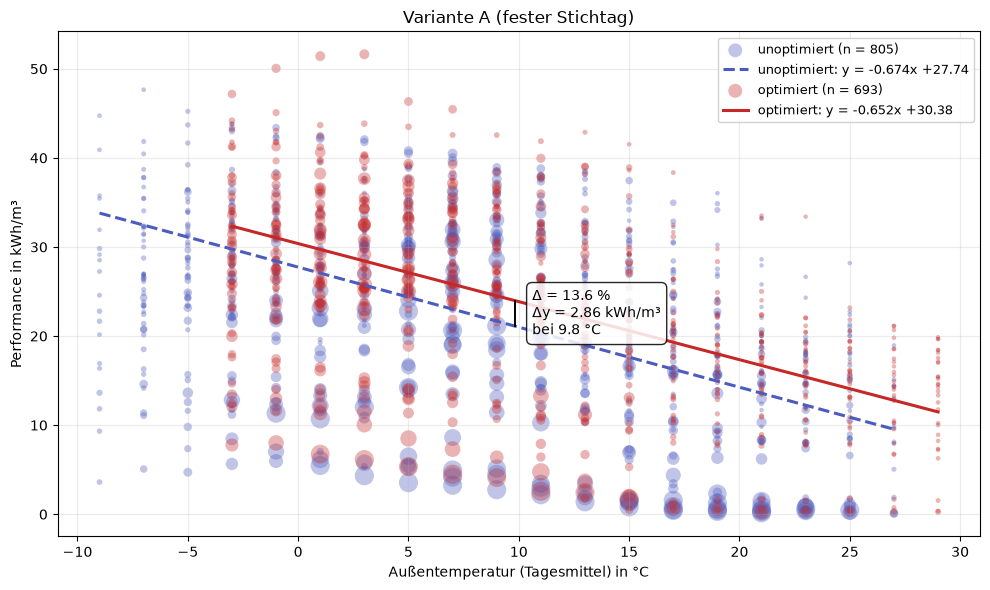

1498 Blasen aus 28,796 Stationstagen -> outputs/performance_variante_a.png


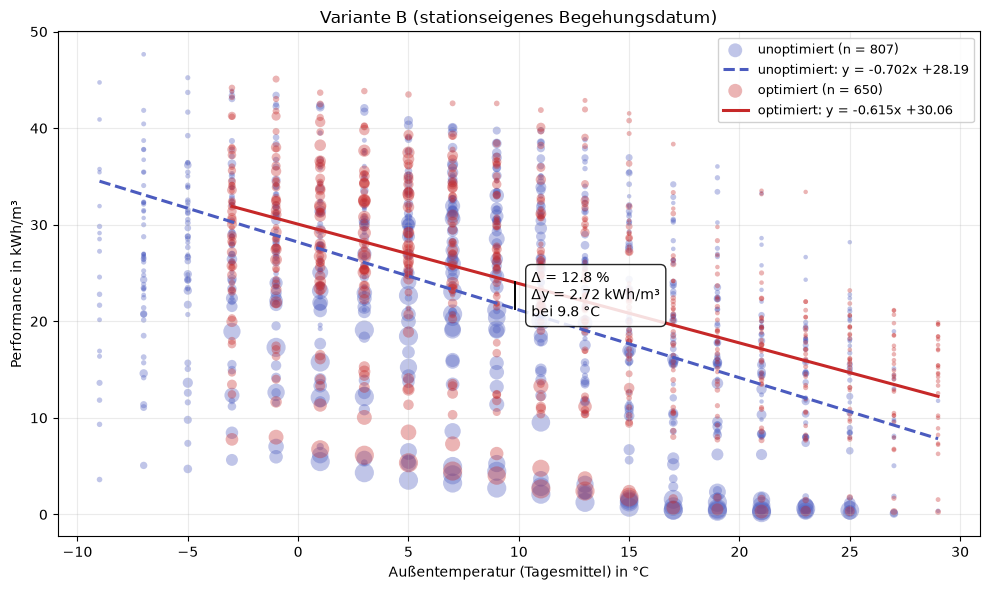

1457 Blasen aus 28,319 Stationstagen -> outputs/performance_variante_b.png


In [13]:
KLASSENBREITE = 2.0   #Temperaturklasse der Blasendarstellung in K

for erg, datei in ((erg_a, "performance_variante_a.png"),
                   (erg_b, "performance_variante_b.png")):
    blasen = perf.blasen_aggregat(erg["daten"], klassenbreite=KLASSENBREITE)
    fig, ax = plt.subplots(figsize=(10, 6))
    perf.blasendiagramm(blasen, erg["fits"], erg["t_ref"],
                        delta=erg["delta"], titel=erg["name"], ax=ax)
    fig.tight_layout()
    fig.savefig(OUTPUTS / datei, dpi=150)
    plt.show()
    print(f"{len(blasen)} Blasen aus {len(erg['daten']):,} Stationstagen "
          f"-> outputs/{datei}")

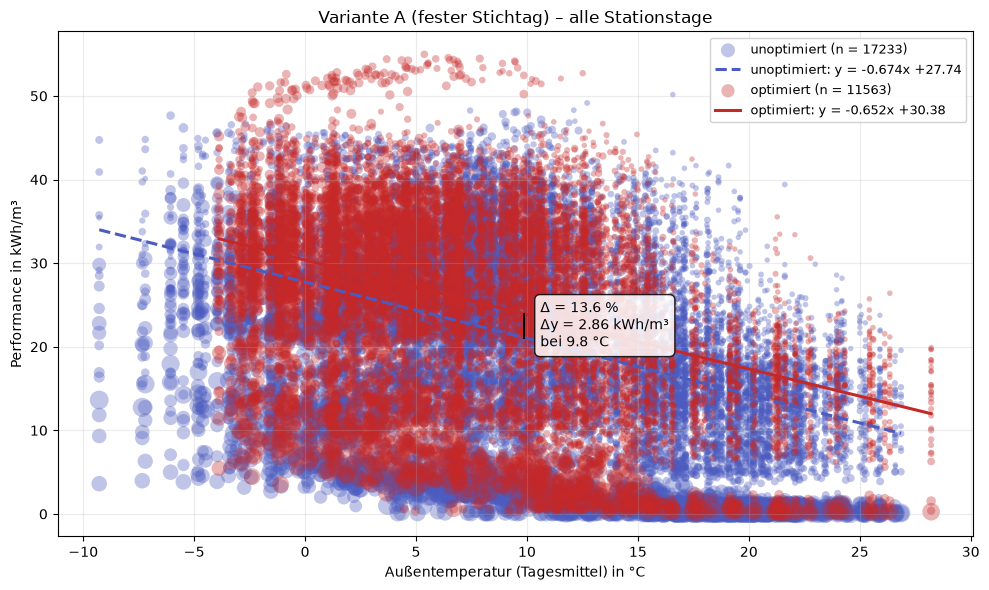

gespeichert: outputs/performance_variante_a_tage.png


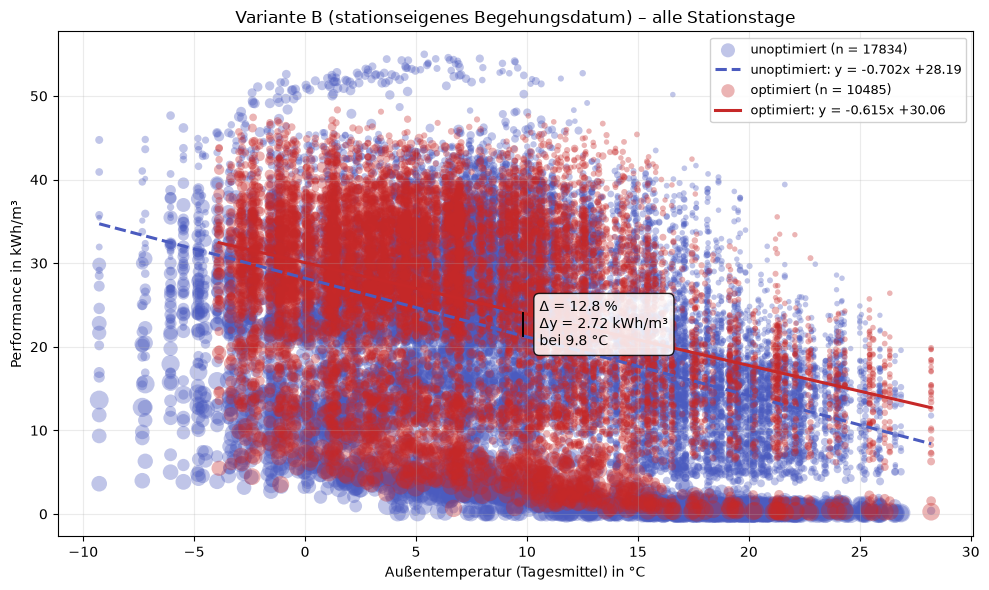

gespeichert: outputs/performance_variante_b_tage.png


In [14]:
#Gegenprobe ohne Verdichtung: dieselben Geraden auf allen Tageswerten
for erg, datei in ((erg_a, "performance_variante_a_tage.png"),
                   (erg_b, "performance_variante_b_tage.png")):
    fig, ax = plt.subplots(figsize=(10, 6))
    perf.blasendiagramm(erg["daten"], erg["fits"], erg["t_ref"],
                        delta=erg["delta"],
                        titel=f"{erg['name']} – alle Stationstage", ax=ax)
    fig.tight_layout()
    fig.savefig(OUTPUTS / datei, dpi=150)
    plt.show()
    print(f"gespeichert: outputs/{datei}")

## 8 – Vergleich mit den Zahlen der ÜZ

Die vier Zahlen der Folie neben unseren, jeweils mit Bezugspunkt.

In [15]:
vergleich = pd.DataFrame({
    "Kennzahl": ["Steigung unoptimiert", "Steigung optimiert",
                 "Achsenabschnitt unoptimiert", "Achsenabschnitt optimiert",
                 "Bezugspunkt (°C)", "Delta (kWh/m³)", "Delta (%)",
                 "Stationen", "Beobachtungen"],
    "ÜZ (Folie)": [-0.588, -0.423, 21.10, 21.77, 8.8, 2.12, 13.4,
                   "rund 60", "unbekannt"],
})
for erg, spalte in ((erg_a, "Variante A"), (erg_b, "Variante B")):
    z = erg["fits"].set_index("gruppe")
    vergleich[spalte] = [
        round(z.loc[perf.GRUPPE_VOR, "steigung"], 3),
        round(z.loc[perf.GRUPPE_NACH, "steigung"], 3),
        round(z.loc[perf.GRUPPE_VOR, "achsenabschnitt"], 2),
        round(z.loc[perf.GRUPPE_NACH, "achsenabschnitt"], 2),
        round(erg["t_ref"], 1),
        round(erg["delta"]["delta_kwh_m3"], 2),
        round(erg["delta"]["delta_prozent"], 1),
        int(erg["modell"]["n_cluster"]),
        int(erg["modell"]["n"]),
    ]
display(vergleich.set_index("Kennzahl"))

,ÜZ (Folie),Variante A,Variante B
Kennzahl,,,
Steigung unoptimiert,-0.588,-0.674,-0.702
Steigung optimiert,-0.423,-0.652,-0.615
Achsenabschnitt unoptimiert,21.1,27.740,28.190
Achsenabschnitt optimiert,21.77,30.380,30.060
Bezugspunkt (°C),8.8,9.800,9.800
Delta (kWh/m³),2.12,2.860,2.720
Delta (%),13.4,13.600,12.800
Stationen,rund 60,51.000,51.000
Beobachtungen,unbekannt,28796.000,28319.000


**Was passt:**

- Prozentwert: 13,6 % (A) und 12,8 % (B) gegen 13,4 % auf der Folie
- Absolutes Delta bei uns 2,7 bis 2,9 kWh/m³ statt 2,12. Passt zum höheren Bezugspunkt (9,8 °C statt 8,8 °C).

**Was nicht passt:**

- Niveau: unsere unoptimierte Gerade liegt am Bezugspunkt bei 21,1 kWh/m³, die der Folie bei 15,9. Das sind gut 5 K mehr Spreizung. Woran das liegt, ist offen.
- Steigungen: unoptimiert −0,67 bis −0,70 (Folie −0,588), optimiert −0,65 bzw. −0,61 (Folie −0,423). Abstand der Steigungen bei der Folie 0,165, bei uns 0,02 bzw. 0,09.

**Mögliche Gründe:**

- Andere Stationsmenge: Folie ca. 60 optimierte HAST im ganzen Versorgungsgebiet, wir 51 Zähler in Wiesentheid (45 davon mit Nachher-Phase)
- Anderer Zeitraum: unsere Historie endet 2025-07-11, also nur ein voller Winter nach den Begehungen vom September 2024
- Vermutlich andere Aggregation: wir rechnen auf Stationstagen
- Filterung: bei uns fallen 38 % der Stationstage an der Volumenschwelle raus, die Schwelle der ÜZ kennen wir nicht

Für den Vergleich der beiden Gruppen ist das Niveau egal, für absolute Aussagen zu Netzverlusten nicht.

In [16]:
#Gegenprobe zum Zeitraum: wie verteilt sich die Nachher-Phase auf die Jahre
nach = var_b[var_b["gruppe"] == perf.GRUPPE_NACH]
display(nach.groupby(pd.DatetimeIndex(nach["datum"]).to_period("Q"))
        .agg(tage=("performance", "size"),
             zaehler=("meter", "nunique"),
             t_out_mittel=("t_out_tag", "mean")).round(1))

,tage,zaehler,t_out_mittel
datum,,,
2024Q3,179,25,13.7
2024Q4,3140,43,6.0
2025Q1,3855,44,3.6
2025Q2,3047,44,14.5
2025Q3,264,33,21.1


## 9 – Nachlieferung bis Juli 2026 (fünf Zähler)

Für fünf Zähler gibt es inzwischen Daten bis 20. Juli 2026, ein Jahr mehr als in den CSV-Exporten.

- Vorteil: eine zusätzliche volle Heizperiode in der Nachher-Phase
- Haken: Energie und Volumen fehlen im neuen Format als Zählerstand und müssen aus Leistung und Volumenstrom integriert werden

Zuerst wird geprüft, wie gut die Integration ist.

In [17]:
ODS_METER = sorted(lts.discover_meter_ods())


def serie_mit_ods(zid, mit_ods=True):
    df = lts.load_meter_timeseries(zid, mit_ods=mit_ods,
                                   zaehlerstaende_integrieren=mit_ods)
    return df.rename(columns=SPALTEN).set_index("Timestamp").sort_index()


#Gegenprobe: dieselben Tage einmal aus gemessenen Zaehlerstaenden und
#einmal aus integrierter Leistung. Die CSV liefert beides, deshalb ist
#der Fehler der Integration hier direkt messbar
zeilen = []
for zid in ODS_METER:
    a = perf.tagesperformance(serie_mit_ods(zid, mit_ods=False))
    b = perf.tagesperformance(
        lts.ergaenze_zaehlerstaende(lts.load_meter_ods(zid))
        .rename(columns=SPALTEN).set_index("Timestamp"))
    m = a.merge(b, on="datum", suffixes=("_mess", "_int"))
    m = m[m["gueltig_mess"] & m["gueltig_int"]]
    d = m["performance_int"] - m["performance_mess"]
    zeilen.append({
        "meter": zid, "tage": len(m),
        "median_abw": d.median(),
        "median_abw_prozent": 100 * (d / m["performance_mess"]).median(),
        "p05": d.quantile(0.05), "p95": d.quantile(0.95),
        "korrelation": m["performance_int"].corr(m["performance_mess"]),
    })
display(pd.DataFrame(zeilen).round(3))

,meter,tage,median_abw,median_abw_prozent,p05,p95,korrelation
0,68956347,261,-0.808,-2.646,-6.887,6.981,0.898
1,68956371,114,-0.023,-0.060,-3.030,2.645,0.856
2,68956372,410,-0.091,-0.817,-0.927,1.213,0.997
3,72167783,338,-0.042,-0.137,-0.421,0.504,1.000
4,80912172,212,0.478,2.052,-4.166,4.491,0.768


- Die Integration trifft das Niveau, aber nicht den einzelnen Tag.
- Abweichung im Median je Station −2,7 bis +2,1 %, Korrelation 0,77 bis 1,00.
- Für Vergleiche über Monate brauchbar, für Tagesaussagen nicht.
- Die Zahlen unten sind deshalb unsicherer als in Abschnitt 5, vor allem in der Nachher-Phase (komplett integriert).

In [18]:
beg_ods = {z: d for z, d in erste_begehung.items() if z in ODS_METER}
print(f"{len(beg_ods)} der {len(ODS_METER)} Zaehler haben eine Begehung")

zeilen, fits = [], []
for mit_ods in (False, True):
    serien_ods = {z: serie_mit_ods(z, mit_ods) for z in beg_ods}
    #die Aussentemperatur oben endet mit den CSV-Exporten; fuer die
    #Nachlieferung muss sie bis Juli 2026 reichen, sonst faellt genau der
    #neue Teil beim Verknuepfen wieder heraus
    bis = max(d.index[-1] for d in serien_ods.values())
    t_lang = weather.load_outdoor_temperature(
        hist_von, bis + pd.Timedelta(hours=23), allow_download=False)
    t = perf.mit_aussentemperatur(perf.performance_tabelle(serien_ods), t_lang)
    t = t[t["gueltig"]].dropna(subset=["t_out_tag"])
    g = perf.gruppe_je_station(t, beg_ods, puffer_tage=PUFFER_TAGE)
    g = g.dropna(subset=["gruppe"])
    stand = "mit ODS" if mit_ods else "nur CSV"
    for name, teil in g.groupby("gruppe"):
        zeilen.append({
            "stand": stand, "gruppe": name, "tage": len(teil),
            "zaehler": teil["meter"].nunique(),
            "performance_median": teil["performance"].median(),
            "t_out_mittel": teil["t_out_tag"].mean(),
            "letzter_tag": teil["datum"].max(),
        })
    #nur vier Zaehler, deshalb ohne clusterrobuste Fehler - zwei Cluster
    #je Gruppe tragen keine Standardfehler
    fits.append(perf.regression_je_gruppe(g, cluster=None).assign(stand=stand))

gruppen = pd.DataFrame(zeilen)
display(gruppen.assign(letzter_tag=gruppen["letzter_tag"].dt.date).round(2))
schieflage = (gruppen.pivot(index="stand", columns="gruppe",
                            values="t_out_mittel")
              .assign(schieflage_k=lambda x: x["optimiert"]
                      - x["unoptimiert"]))
display(schieflage.round(2))
display(pd.concat(fits)[["stand", "gruppe", "n", "steigung",
                         "achsenabschnitt", "r2"]].round(3))


4 der 5 Zaehler haben eine Begehung


,stand,gruppe,tage,zaehler,performance_median,t_out_mittel,letzter_tag
0,nur CSV,optimiert,474,2,21.36,7.71,2025-07-10
1,nur CSV,unoptimiert,1903,4,9.82,10.40,2025-07-10
2,mit ODS,optimiert,1457,4,18.80,8.21,2026-07-19
3,mit ODS,unoptimiert,1911,4,9.62,10.43,2025-07-18


gruppe,optimiert,unoptimiert,schieflage_k
stand,,,
mit ODS,8.21,10.43,-2.23
nur CSV,7.71,10.40,-2.69


,stand,gruppe,n,steigung,achsenabschnitt,r2
0,nur CSV,unoptimiert,1903,-1.268,29.460,0.335
1,nur CSV,optimiert,474,-0.493,23.454,0.366
0,mit ODS,unoptimiert,1911,-1.271,29.469,0.337
1,mit ODS,optimiert,1457,-0.450,21.210,0.107


- Nachher-Phase wächst von 474 auf 1457 Stationstage und reicht jetzt bis Juli 2026.
- Temperaturschieflage sinkt von 2,7 auf 2,2 K, verschwindet aber nicht. Die Begehungen lagen im Spätsommer, die Vorher-Fenster enthalten also viele Sommertage.
- R² der optimierten Gerade fällt von 0,35 auf 0,11. Hauptgrund ist eine Station, die im Winter 2025/26 praktisch keine Wärme abgenommen hat.
- Das Delta am Bezugspunkt dreht von +1,65 auf −0,48 kWh/m³.

Daraus leiten wir keine Aussage ab: vier Stationen, eine dominiert, Nachher-Werte nur integriert. Mitnehmen kann man die Methodenprüfung.

## 10 – Zusammenfassung

**Reproduziert:**

- Nach der Begehung setzen die Stationen bei vergleichbarer Außentemperatur rund 2,7 bis 2,9 kWh/m³ mehr um, das sind ca. 2,3 bis 2,5 K mehr Spreizung bzw. 12,8 bis 13,6 %. Die Folie nennt 13,4 %.

**Belastbar:**

- Höhenunterschied der Geraden (auch clusterrobust und volumengewichtet)
- Bezugspunkt ist in beiden Gruppen dicht belegt, keine Extrapolation

**Schwach:**

- Steigungsaussage: in keiner Variante signifikant, volumengewichtet dreht sie sich um
- Keine Kontrollgruppe. „Optimiert" ist im Mittel rund 3 K kälter und besteht überwiegend aus dem Winter 2024/25. Der Abstand passt zu einer Wirkung der Begehungen, ist aber kein Nachweis.

**Nächster Schritt:**

- Saison und Begehung trennen: kalendergleicher Vorjahresvergleich plus Kontrollgruppe ohne Begehung, übertragen auf die Performance-Kennzahl

**Offen fürs Team:**

- Fallen die vier Stationen mit Begehung nach Ende der Historie ganz raus?
- Zähler mit auffälliger Abweichung zwischen Kennzahl und gemessener Spreizung: ausschließen oder als eigenen Befund behandeln?